In [1]:
# ==============================================================================
# PHASE 1: DATA ENGINEERING & COMPLIANCE INGESTION
# ==============================================================================
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_absolute_error

# Establish structural reproducibility
np.random.seed(2026)
n_cases = 450

# Simulate District Special Education Tracking Schema
sped_schema = {
    'Case_ID': [f'SPED-AUDIT-{10000+i}' for i in range(n_cases)],
    'School_Campus_ID': [f'CAMPUS-{np.random.randint(101, 116)}' for _ in range(n_cases)],
    'Days_Since_Parental_Consent': np.random.randint(10, 85, n_cases),
    'Evaluation_Type': np.random.choice(['Speech-Language', 'Occupational Therapy', 'Psycho-Educational'], n_cases),
    'Current_Case_Manager_Load': np.random.randint(18, 48, n_cases),
    'Parent_Communication_Log_Count': np.random.randint(1, 15, n_cases)
}

df_sped = pd.DataFrame(sped_schema)
print("Special Education Compliance Registry loaded successfully!")
print(f"Dataset Footprint: {df_sped.shape} active case logs across district schools.\n")
df_sped.head(3)


Special Education Compliance Registry loaded successfully!
Dataset Footprint: (450, 6) active case logs across district schools.



,Case_ID,School_Campus_ID,Days_Since_Parental_Consent,Evaluation_Type,Current_Case_Manager_Load,Parent_Communication_Log_Count
0,SPED-AUDIT-10000,CAMPUS-102,13,Psycho-Educational,39,8
1,SPED-AUDIT-10001,CAMPUS-107,32,Psycho-Educational,44,14
2,SPED-AUDIT-10002,CAMPUS-111,38,Occupational Therapy,20,1


In [2]:
# ==============================================================================
# PHASE 2: COMPLIANCE BOTTLENECK RISK INDEXING
# ==============================================================================
# Calculate standard timeline variance (IDEA standard mandate is 60 days)
df_sped['Days_Over_Mandate'] = df_sped['Days_Since_Parental_Consent'].apply(lambda x: max(0, x - 60))

# Legal Risk Score: Blends timeline variance with case manager workload pressures
df_sped['Legal_Risk_Score'] = (
    (df_sped['Days_Over_Mandate'] * 2.2) +
    (df_sped['Current_Case_Manager_Load'] * 0.8) -
    (df_sped['Parent_Communication_Log_Count'] * 0.5)
).round(1)

# Ensure the score sits on a clean 0 - 100 operational scale
max_risk = df_sped['Legal_Risk_Score'].max()
df_sped['Legal_Risk_Score'] = ((df_sped['Legal_Risk_Score'] / max_risk) * 100).round(1)

# Vectorize Financial Litigation Exposure: $7,500 in state mediation fees per out-of-compliance file
df_sped['Litigation_Exposure_USD'] = df_sped['Days_Over_Mandate'].apply(lambda x: 7500 if x > 0 else 0)

print("Compliance Bottleneck Risk and Financial Litigation Exposure successfully engineered.")
df_sped[['Case_ID', 'School_Campus_ID', 'Legal_Risk_Score', 'Litigation_Exposure_USD']].head(3)


Compliance Bottleneck Risk and Financial Litigation Exposure successfully engineered.


,Case_ID,School_Campus_ID,Legal_Risk_Score,Litigation_Exposure_USD
0,SPED-AUDIT-10000,CAMPUS-102,32.6,0
1,SPED-AUDIT-10001,CAMPUS-107,33.8,0
2,SPED-AUDIT-10002,CAMPUS-111,18.6,0


In [3]:
# ==============================================================================
# PHASE 3: UNSUPERVISED CAMPUS RISK SEGMENTATION
# ==============================================================================
# Roll up individual case metrics to aggregate building-level operational models
campus_summary = df_sped.groupby('School_Campus_ID').agg(
    Average_Case_Manager_Load=('Current_Case_Manager_Load', 'mean'),
    Average_Campus_Risk_Score=('Legal_Risk_Score', 'mean'),
    Total_Litigation_Exposure=('Litigation_Exposure_USD', 'sum'),
    Total_Active_Cases=('Case_ID', 'count')
).reset_index()

# Extract clustering vectors and standardize features
X_cluster = campus_summary[['Average_Campus_Risk_Score', 'Total_Litigation_Exposure']].values
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_cluster)

# Segment campuses into 3 operational risk tiers
kmeans = KMeans(n_clusters=3, random_state=2026, n_init=10)
campus_summary['Risk_Tier_Cluster'] = kmeans.fit_predict(X_scaled)

print("District campus distribution across operational risk clusters:")
print(campus_summary['Risk_Tier_Cluster'].value_counts().to_dict())


District campus distribution across operational risk clusters:
{0: 8, 1: 5, 2: 2}


In [4]:
# ==============================================================================
# PHASE 4: PRESCRIPTIVE CASEWORKER RESOURCE REALLOCATION
# ==============================================================================
# Mapping risk clusters to clear strategic organizational definitions
cluster_means = campus_summary.groupby('Risk_Tier_Cluster')['Average_Campus_Risk_Score'].mean()
critical_cluster_id = cluster_means.idxmax()

campus_summary['Operational_Action_Plan'] = campus_summary['Risk_Tier_Cluster'].apply(
    lambda x: 'IMMEDIATE DEPLOYMENT: REDISTRIBUTE CASE TIMELINES' if x == critical_cluster_id else 'MONITOR ROUTINE COMPLIANCE'
)

optimized_district_schedule = campus_summary.sort_values(by='Total_Litigation_Exposure', ascending=False)
print("Prescriptive district caseworker reallocation matrix successfully executed.")
optimized_district_schedule[['School_Campus_ID', 'Total_Active_Cases', 'Total_Litigation_Exposure', 'Operational_Action_Plan']]


Prescriptive district caseworker reallocation matrix successfully executed.


,School_Campus_ID,Total_Active_Cases,Total_Litigation_Exposure,Operational_Action_Plan
9,CAMPUS-110,32,105000,IMMEDIATE DEPLOYMENT: REDISTRIBUTE CASE TIMELINES
8,CAMPUS-109,29,90000,IMMEDIATE DEPLOYMENT: REDISTRIBUTE CASE TIMELINES
0,CAMPUS-101,38,75000,MONITOR ROUTINE COMPLIANCE
14,CAMPUS-115,31,75000,MONITOR ROUTINE COMPLIANCE
13,CAMPUS-114,36,75000,MONITOR ROUTINE COMPLIANCE
5,CAMPUS-106,29,75000,MONITOR ROUTINE COMPLIANCE
3,CAMPUS-104,33,75000,MONITOR ROUTINE COMPLIANCE
11,CAMPUS-112,29,67500,IMMEDIATE DEPLOYMENT: REDISTRIBUTE CASE TIMELINES
4,CAMPUS-105,34,67500,MONITOR ROUTINE COMPLIANCE
6,CAMPUS-107,31,67500,IMMEDIATE DEPLOYMENT: REDISTRIBUTE CASE TIMELINES


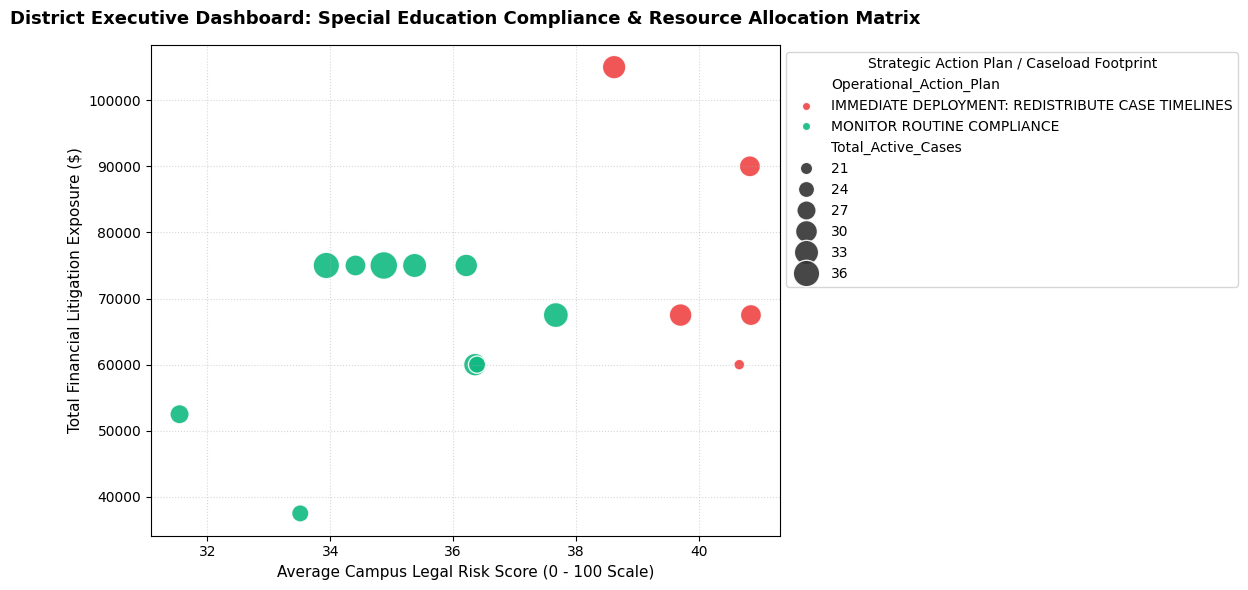

In [5]:
# ==============================================================================
# PHASE 5: EXECUTIVE DISTRICT VISUALIZATION
# ==============================================================================
plt.figure(figsize=(12, 6))

sns.scatterplot(
    x='Average_Campus_Risk_Score',
    y='Total_Litigation_Exposure',
    hue='Operational_Action_Plan',
    size='Total_Active_Cases',
    sizes=(60, 400),
    palette={'IMMEDIATE DEPLOYMENT: REDISTRIBUTE CASE TIMELINES': '#EF4444', 'MONITOR ROUTINE COMPLIANCE': '#10B981'},
    data=optimized_district_schedule,
    alpha=0.9
)

plt.title('District Executive Dashboard: Special Education Compliance & Resource Allocation Matrix', fontsize=13, weight='bold', pad=15)
plt.xlabel('Average Campus Legal Risk Score (0 - 100 Scale)', fontsize=11)
plt.ylabel('Total Financial Litigation Exposure ($)', fontsize=11)
plt.grid(True, linestyle=':', alpha=0.5)
plt.legend(title='Strategic Action Plan / Caseload Footprint', loc='upper left', bbox_to_anchor=(1, 1))
plt.tight_layout()
plt.show()
